In [ ]:
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from daft import PGM

In [4]:
def pgm_to_img(pgm):
    """Render a PGM to an RGBA image array."""
    pgm.render()
    ax = plt.gca()
    ax.set_aspect('equal')
    buf = io.BytesIO()
    fig = plt.gcf()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=150)
    buf.seek(0)
    img = mpimg.imread(buf)
    plt.close(fig)
    return img

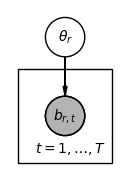

In [10]:
pgm = PGM()
pgm.add_node("theta", r"$\theta_{r}$", 1, 2)
pgm.add_node("batch", r"$b_{r,t}$", 1, 1, observed=True)
pgm.add_plate([0.4, 0.4, 1.2, 1.2], label=r"$t = 1, \ldots, T$",
              position="bottom right")
pgm.add_edge("theta", "batch")

pgm.render()
plt.gca().set_aspect('equal')
plt.show()

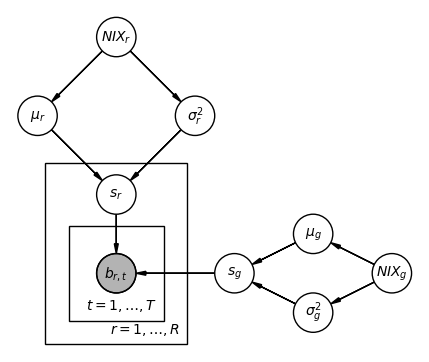

In [26]:
pgm = PGM()
pgm.add_node("nix_g", r"$NIX_g$", 4.5, 1)
pgm.add_node("nix_r", r"$NIX_r$", 1, 4)
pgm.add_node("s_g", r"$s_g$", 2.5, 1)
pgm.add_node("mu_r", r"$\mu_r$", 0, 3)
pgm.add_node("sigma_r", r"$\sigma^2_r$", 2, 3)
pgm.add_node("mu_g", r"$\mu_g$", 3.5, 1.5)
pgm.add_node("sigma_g", r"$\sigma^2_g$", 3.5, 0.5)

pgm.add_plate([0.1, 0.1, 1.8, 2.3], label=r"$r = 1, \ldots, R$",
              position="bottom right")
pgm.add_node("s", r"$s_{r}$", 1, 2)
pgm.add_node("batch", r"$b_{r,t}$", 1, 1, observed=True)
pgm.add_plate([0.4, 0.4, 1.2, 1.2], label=r"$t = 1, \ldots, T$",
              position="bottom right")

pgm.add_edge("nix_r", "mu_r")
pgm.add_edge("nix_r", "sigma_r")
pgm.add_edge("mu_r", "s")
pgm.add_edge("sigma_r", "s")
pgm.add_edge("s", "batch")
pgm.add_edge("s_g", "batch")
pgm.add_edge("nix_g", "mu_g")
pgm.add_edge("nix_g", "sigma_g")
pgm.add_edge("mu_g", "s_g")
pgm.add_edge("sigma_g", "s_g")

pgm.render()
plt.gca().set_aspect('equal')
plt.show()